In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue',  'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [2]:
S2S = '/Users/oskarsvensson/Science/FILES/ARTICLES/Submitted/Hst1_self/MARTINI/convergence/'
S2D = '/Users/oskarsvensson/Science/FILES/ARTICLES/Submitted/Hst1_self/phospo_mimics/analysis/S2D/convegence/'
S2E = '/Users/oskarsvensson/Science/FILES/ARTICLES/Submitted/Hst1_self/phospo_mimics/analysis/S2E/convergence/'
pairs = list(combinations(range(32), 2))

In [3]:
def plot_func(work_dir, axis1, axis2):
    color_pick = 0
    t, dist = np.genfromtxt((work_dir + '1/Chain0/0_1.xvg'), usecols=(0, 1), skip_header=24, unpack=True)
    dist_total = np.zeros_like(dist)
    
    for nr in range(1, 6):
        counter = 0
        for pair in pairs:
            dist = np.genfromtxt((work_dir + str(nr) + '/Chain' + str(pair[0]) + '/' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                                 usecols=(1), skip_header=24, unpack=True)
            if counter == 0:
                dist_ave = dist
            else:
                dist_ave += dist
            counter += 1
        ax[axis1, axis2].plot((t*(10**-6)), (dist_ave/counter), color=color_list[color_pick])
        dist_total += (dist_ave/counter)
        color_pick += 24
    return t, (dist_total/5)

2.8153776898303864
2.8501606579664522
2.6590189325417404


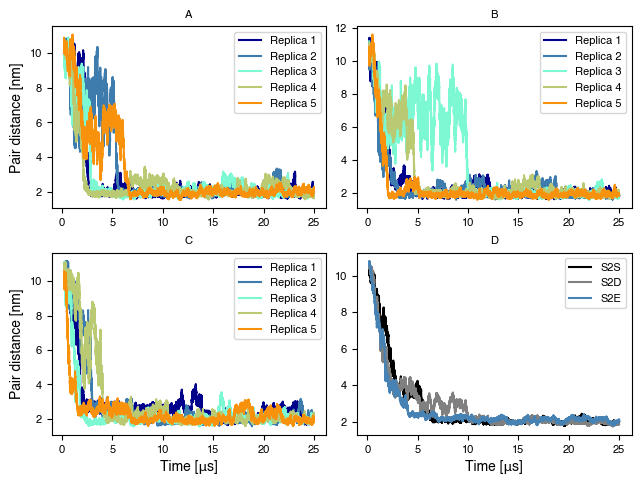

In [63]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=((16*cm), (12*cm)), layout='constrained')
ax[0, 0].tick_params(labelsize=font)
ax[0, 1].tick_params(labelsize=font)
ax[1, 0].tick_params(labelsize=font)
ax[1, 1].tick_params(labelsize=font)

work_dir = S2S + 'Trial'
t, dist = plot_func(work_dir, 0, 0)
ax[1, 1].plot((t*(10**-6)), dist, color='black')
print(sum(dist)/len(dist))
work_dir = S2D + 'Trial'
t, dist = plot_func(work_dir, 0, 1)
ax[1, 1].plot((t*(10**-6)), dist, color='grey')
print(sum(dist)/len(dist))
work_dir = S2E + 'Trial'
t, dist = plot_func(work_dir, 1, 0)
ax[1, 1].plot((t*(10**-6)), dist, color='steelblue')
print(sum(dist)/len(dist))

ax[0, 0].legend(['Replica 1', 'Replica 2', 'Replica 3', 'Replica 4', 'Replica 5'], fontsize=font)
ax[0, 1].legend(['Replica 1', 'Replica 2', 'Replica 3', 'Replica 4', 'Replica 5'], fontsize=font)
ax[1, 0].legend(['Replica 1', 'Replica 2', 'Replica 3', 'Replica 4', 'Replica 5'], fontsize=font)
ax[1, 1].legend(['S2S', 'S2D', 'S2E'], fontsize=font)
ax[0, 0].set_title('A', fontsize=font)
ax[0, 1].set_title('B', fontsize=font)
ax[1, 0].set_title('C', fontsize=font)
ax[1, 1].set_title('D', fontsize=font)
ax[0, 0].set_ylabel('Pair distance [nm]', fontsize=font_label)
ax[1, 0].set_ylabel('Pair distance [nm]', fontsize=font_label)
ax[1, 0].set_xlabel('Time [μs]', fontsize=font_label)
ax[1, 1].set_xlabel('Time [μs]', fontsize=font_label)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/phospho_convergence.pdf', dpi=1000)

In [4]:
def A_N_func(work_dir):
    temp = np.genfromtxt((work_dir + '/0.xvg'), usecols=(2), skip_header=28, unpack=True)
    rg_array = np.zeros((len(temp), 32))
    for nr in range(0, 32, 1):
        temp = np.genfromtxt((work_dir + str(nr) + '.xvg'), usecols=(2), skip_header=28, unpack=True)
        rg_array[:, nr] = temp

    pairs = list(combinations(range(0, 32, 1), 2))
    t, temp = np.genfromtxt((work_dir + 'Chain0/0_0.xvg'), usecols=(0, 1), skip_header=24, unpack=True)
    dist_array = np.zeros((len(temp), len(pairs)))
    counter = 0
    for pair in pairs:
        temp = np.genfromtxt((work_dir + 'Chain' + str(pair[0]) + '/' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                             usecols=(1), skip_header=24, unpack=True)
        dist_array[:, counter] = temp
        counter += 1

    asso_list = []
    asso_array = np.zeros_like(dist_array)
    for (dist_entry, rg_entry, asso_entry) in zip(dist_array, rg_array, asso_array):
        asso_count = 0
        counter = 0
        for dist_point in dist_entry:
            temp = pairs[counter]
            cutoff = rg_entry[temp[0]] + rg_entry[temp[1]]
            if dist_point <= cutoff:
                asso_count += 1
                asso_entry[counter] += 1
            counter += 1
        asso_list.append(asso_count)
    return t, asso_list, asso_array

In [5]:
def asso_counting(asso_list):
    counter = 0
    asso_range = range(np.min(asso_list), np.max(asso_list), 1)
    asso_count = np.zeros_like(asso_range)
    for point in asso_range:
        for element in asso_list:
            if element == point:
                asso_count[counter] += 1
        counter += 1
    return asso_range, asso_count

In [6]:
def cluster_check(asso_array, pairs):
    clusters = []
    for asso_entry in asso_array:
        connections = []
        counter = 0
        for point in asso_entry:
            if point == 1:
                connections.append(pairs[counter])
            counter += 1
        G = nx.Graph()
        G.add_edges_from(connections)
        components = list(nx.connected_components(G))
        clusters.append(len(components))
    
    cluster_range = range(np.min(clusters), np.max(clusters), 1)
    cluster_count = np.zeros_like(cluster_range)
    counter = 0
    for point in cluster_range:
        for element in clusters:
            if element == point:
                cluster_count[counter] += 1
        counter += 1
    return cluster_range, cluster_count

In [35]:
def trial_ave(work_dir):
    replica_ave = []
    std_rep = []
    for trial in range(1, 6, 1):
        t, asso_list, asso_array = A_N_func(work_dir + '/Trial' + str(trial) + '/')
        asso_list = np.array(asso_list)
        asso_range_temp, asso_count = asso_counting(asso_list)
        cluster_range_temp, cluster_count = cluster_check(asso_array, pairs)
        replica_ave.append(sum(asso_list[20000:-1])/len(asso_list[20000:-1]))
        std_rep.append(np.std(np.array(asso_list[20000:-1])))
        
        if trial == 1:
            asso_total = asso_list
            asso_total_count = asso_count
            asso_range = asso_range_temp
            cluster_range = cluster_range_temp
            cluster_total_count = cluster_count
            bar_thing = sum(asso_array[-1])
            std_array = np.zeros((5, len(asso_total)))
            std_array[trial - 1] = asso_list
        else:
            asso_total += asso_list
            bar_thing += sum(asso_array[-1])
            std_array[trial - 1] = asso_list
            
            if len(asso_total_count) > len(asso_count):
                while len(asso_total_count) > len(asso_count):
                    asso_count = np.append(asso_count, 0)
                asso_total_count += asso_count
            elif len(asso_total_count) < len(asso_count):
                while len(asso_total_count) < len(asso_count):
                    asso_total_count = np.append(asso_total_count, 0)
                asso_total_count += asso_count

            if len(cluster_total_count) > len(cluster_count):
                while len(cluster_total_count) > len(cluster_count):
                    cluster_count = np.append(cluster_count, 0)
                cluster_total_count += cluster_count
            elif len(cluster_total_count) < len(cluster_count):
                while len(cluster_total_count) < len(cluster_count):
                    cluster_total_count = np.append(cluster_total_count, 0)
                cluster_total_count += cluster_count
        
            if len(asso_range) < len(asso_range_temp):
                asso_range = asso_range_temp
            if len(cluster_range) < len(cluster_range_temp):
                cluster_range = cluster_range_temp
        
    asso_total = asso_total/5
    asso_total_count = asso_total_count/5
    cluster_total_count = cluster_total_count/5
    bar_thing = bar_thing/5
    std_asso = np.std(std_array, axis=0)
    return (t*(10**-6)), asso_total, asso_range, asso_total_count, replica_ave, bar_thing, asso_array, cluster_range, cluster_total_count, std_rep, std_asso


In [8]:
def cluster_vis(asso_array, axis1, axis2):
    connections = []
    counter = 0
    for a in asso_array:
        if a == 1:
            connections.append(pairs[counter])
        counter += 1
    print(len(connections))
    
    G = nx.Graph()
    G.add_edges_from(connections)
    colors = ['darkblue', 'aquamarine', 'darkorange']
    cmap = LinearSegmentedColormap.from_list('mycmap', colors)

    source_numbers = sorted(set(a for a, b in connections))
    n = len(source_numbers)
    source_colors = {
        number: cmap(i / max(n - 1, 1))
        for i, number in enumerate(source_numbers)}

    edge_colors = [
        source_colors[a]
        for a, b in connections]
    pos = nx.spring_layout(G, seed=44, k=1.2)

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax[axis1, axis2],
        edge_color=edge_colors,
        width=1.2,
        alpha=0.70,
        connectionstyle="arc3,rad=0.12")
    
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax[axis1, axis2],
        node_size=50,        
        node_color='white',
        edgecolors='black',
        linewidths=1.6)

203
218
227


/var/folders/5p/n17l_b1j1blc40n8pdg8y9bh0000gn/T/ipykernel_89892/2394204079.py:26: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


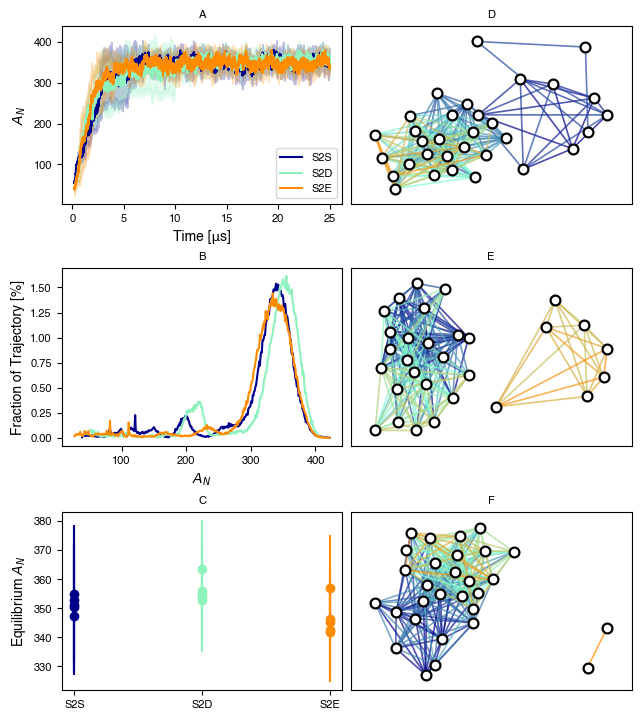

In [42]:
fig, ax = plt.subplots(ncols=2, nrows=3, figsize=((16*cm), (18*cm)), layout='constrained')
ax[0, 0].tick_params(labelsize=font)
ax[1, 0].tick_params(labelsize=font)
ax[2, 0].tick_params(labelsize=font)
ax[0, 1].tick_params(labelsize=font)
ax[1, 1].tick_params(labelsize=font)
ax[2, 1].tick_params(labelsize=font)

t, asso_total, asso_range, asso_total_count, replica_ave, bar_thing, asso_array_S2S, cluster_range, cluster_total_count, std_rep, std_asso = trial_ave(S2S)
ax[0, 0].plot(t, asso_total, color=color_list[0], label='S2S')
ax[0, 0].fill_between(t, asso_total - std_asso, asso_total + std_asso, alpha=0.25, color=color_list[0])
ax[1, 0].plot(asso_range, ((asso_total_count/sum(asso_total_count))*100), color=color_list[0])
for (rep, s) in zip(replica_ave, std_rep):
    ax[2, 0].errorbar('S2S', rep, yerr=s, color=color_list[0], marker='o', linestyle='')
#print(asso_range)

t, asso_total, asso_range, asso_total_count, replica_ave, bar_thing, asso_array_S2D, cluster_range, cluster_total_count, std_rep, std_asso = trial_ave(S2D)
ax[0, 0].plot(t, asso_total, color=color_list[55], label='S2D')
ax[0, 0].fill_between(t, asso_total - std_asso, asso_total + std_asso, alpha=0.25, color=color_list[55])
ax[1, 0].plot(asso_range, ((asso_total_count/sum(asso_total_count))*100), color=color_list[55])
for (rep, s) in zip(replica_ave, std_rep):
    ax[2, 0].errorbar('S2D', rep, yerr=s, color=color_list[55], marker='o', linestyle='')
#print(asso_range)

t, asso_total, asso_range, asso_total_count, replica_ave, bar_thing, asso_array_S2E, cluster_range, cluster_total_count, std_re, std_asso = trial_ave(S2E)
ax[0, 0].plot(t, asso_total, color=color_list[99], label='S2E')
ax[0, 0].fill_between(t, asso_total - std_asso, asso_total + std_asso, alpha=0.25, color=color_list[99])
ax[1, 0].plot(asso_range, ((asso_total_count/sum(asso_total_count))*100), color=color_list[99])
for (rep, s) in zip(replica_ave, std_rep):
    ax[2, 0].errorbar('S2E', rep, yerr=s, color=color_list[99], marker='o', linestyle='')
#print(asso_range)

cluster_vis(asso_array_S2S[1640], 0, 1)
cluster_vis(asso_array_S2D[1225], 1, 1)
cluster_vis(asso_array_S2E[525], 2, 1)

#ax[1, 0].axvline(215, color='black', alpha=0.5, linestyle='--')
#ax[1, 0].axvline(218, color='black', alpha=0.5, linestyle='--')
#ax[1, 0].axvline(227, color='black', alpha=0.5, linestyle='--')

ax[0, 0].set_title("A", fontsize=font)
ax[1, 0].set_title("B", fontsize=font)
ax[2, 0].set_title("C", fontsize=font)
ax[0, 1].set_title("D", fontsize=font)
ax[1, 1].set_title("E", fontsize=font)
ax[2, 1].set_title("F", fontsize=font)
ax[0, 0].set_ylabel('$A_{N}$', fontsize=font_label)
ax[2, 0].set_ylabel('Equilibrium $A_{N}$', fontsize=font_label)
ax[1, 0].set_ylabel('Fraction of Trajectory [%]', fontsize=font_label)
ax[0, 0].set_xlabel('Time [μs]', fontsize=font_label)
ax[1, 0].set_xlabel('$A_{N}$', fontsize=font_label)
ax[0, 0].legend(fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/phospho_mimic.pdf', dpi=1000)

In [44]:
print(t[20000])

20.2


In [ ]:
connections = []
counter = 0
for a in asso_array_S2S[1600]:
    if a == 1:
        connections.append(pairs[counter])
    counter += 1
print(len(connections))

G = nx.Graph()
G.add_edges_from(connections)

colors = ['darkblue', 'aquamarine', 'darkorange']

cmap = LinearSegmentedColormap.from_list(
    'mycmap',
    colors
)

source_numbers = sorted(set(a for a, b in connections))

n = len(source_numbers)

source_colors = {
    number: cmap(i / max(n - 1, 1))
    for i, number in enumerate(source_numbers)
}

edge_colors = [
    source_colors[a]
    for a, b in connections
]

pos = nx.spring_layout(
    G,
    seed=44,
    k=1.2
)

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax[1, 1],
    edge_color=edge_colors,
    width=1.2,
    alpha=0.70,
    connectionstyle="arc3,rad=0.12"
)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax[1, 1],
    node_size=50,          # all nodes equal size
    node_color='white',
    edgecolors='black',
    linewidths=1.6
)

In [ ]:
connections = []
counter = 0
for a in asso_array[290]:
    if a == 1:
        connections.append(pairs[counter])
    counter += 1
print(len(connections))

G = nx.Graph()
G.add_edges_from(connections)

colors = ['darkblue', 'aquamarine', 'darkorange']

cmap = LinearSegmentedColormap.from_list(
    'mycmap',
    colors
)

source_numbers = sorted(set(a for a, b in connections))

n = len(source_numbers)

source_colors = {
    number: cmap(i / max(n - 1, 1))
    for i, number in enumerate(source_numbers)
}

edge_colors = [
    source_colors[a]
    for a, b in connections
]

pos = nx.spring_layout(
    G,
    seed=44,
    k=1.2
)

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax[1, 1],
    edge_color=edge_colors,
    width=1.2,
    alpha=0.70,
    connectionstyle="arc3,rad=0.12"
)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax[1, 1],
    node_size=50,          # all nodes equal size
    node_color='white',
    edgecolors='black',
    linewidths=1.6
)

#nx.draw_networkx_labels(
#    G,
#    pos,
#    ax=ax[1, 1],
#    font_size=4,
#    font_weight='bold'
#)


In [321]:
clusters = []
for asso_entry in asso_array:
    connections = []
    counter = 0
    for point in asso_entry:
        if point == 1:
            connections.append(pairs[counter])
        counter += 1
    G = nx.Graph()
    G.add_edges_from(connections)
    components = list(nx.connected_components(G))
    clusters.append(len(components))


cluster_range = range(np.min(clusters), np.max(clusters), 1)
cluster_count = np.zeros_like(cluster_range)
print(clusters)

for point in cluster_range:
    for element in clusters:
        if element == point:
            cluster_count[counter] += 1
    counter += 1

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

IndexError: index 496 is out of bounds for axis 0 with size 7

In [329]:
clusters = []
for asso_entry in asso_array:
    connections = []
    counter = 0
    for point in asso_entry:
        if point == 1:
            connections.append(pairs[counter])
        counter += 1
    G = nx.Graph()
    G.add_edges_from(connections)
    components = list(nx.connected_components(G))
    clusters.append(len(components))

cluster_range = range(np.min(clusters), np.max(clusters), 1)
cluster_count = np.zeros_like(cluster_range)
counter = 0
for point in cluster_range:
    for element in clusters:
        if element == point:
            cluster_count[counter] += 1
    counter += 1
print(cluster_count)

[7037 6714 5705 3351 1436  437  108]


[{0, 20}, {1, 3, 4, 9, 14, 19, 22, 24}, {2, 5, 18, 26, 27, 31}, {8, 6}, {17, 11}, {25, 23}]


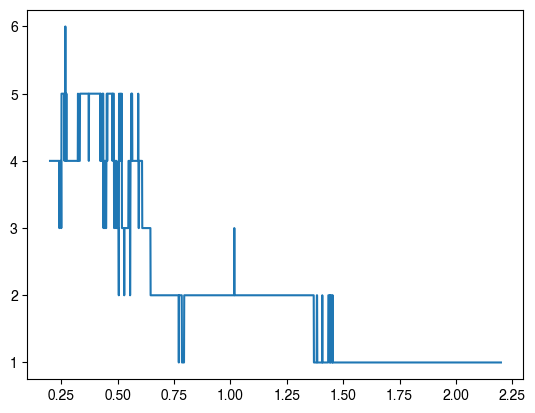

In [323]:
plt.plot(t[0:2000], test[0:2000])
print(components)

In [276]:
G = nx.Graph()
G.add_edges_from(connections)

components = list(nx.connected_components(G))

print(f"Number of clusters: {len(components)}")

Number of clusters: 1


In [465]:
connections = []
counter = 0
for a in asso_array[480]:
    if a == 1:
        connections.append(pairs[counter])
    counter += 1

In [466]:
print(len(connections))
print(connections)

201
[(0, 1), (0, 11), (0, 14), (0, 15), (0, 18), (0, 19), (0, 26), (0, 31), (1, 3), (1, 5), (1, 6), (1, 11), (1, 14), (1, 15), (1, 18), (1, 19), (1, 20), (1, 23), (1, 26), (1, 31), (2, 5), (2, 7), (2, 12), (2, 16), (2, 17), (2, 22), (2, 23), (2, 25), (2, 27), (2, 30), (3, 5), (3, 6), (3, 9), (3, 11), (3, 13), (3, 14), (3, 15), (3, 18), (3, 20), (3, 21), (3, 31), (4, 10), (5, 6), (5, 7), (5, 8), (5, 9), (5, 11), (5, 13), (5, 14), (5, 15), (5, 16), (5, 18), (5, 20), (5, 21), (5, 22), (5, 23), (5, 25), (5, 26), (5, 27), (5, 30), (5, 31), (6, 8), (6, 9), (6, 11), (6, 13), (6, 14), (6, 15), (6, 16), (6, 18), (6, 20), (6, 21), (6, 22), (6, 23), (6, 31), (7, 8), (7, 9), (7, 12), (7, 14), (7, 16), (7, 17), (7, 20), (7, 21), (7, 22), (7, 23), (7, 25), (7, 27), (7, 30), (8, 9), (8, 11), (8, 13), (8, 14), (8, 15), (8, 16), (8, 20), (8, 21), (8, 22), (8, 23), (8, 25), (8, 27), (8, 30), (8, 31), (9, 11), (9, 13), (9, 14), (9, 15), (9, 16), (9, 17), (9, 20), (9, 21), (9, 22), (9, 23), (9, 27), (9, 3

/var/folders/5p/n17l_b1j1blc40n8pdg8y9bh0000gn/T/ipykernel_20288/1300162062.py:25: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


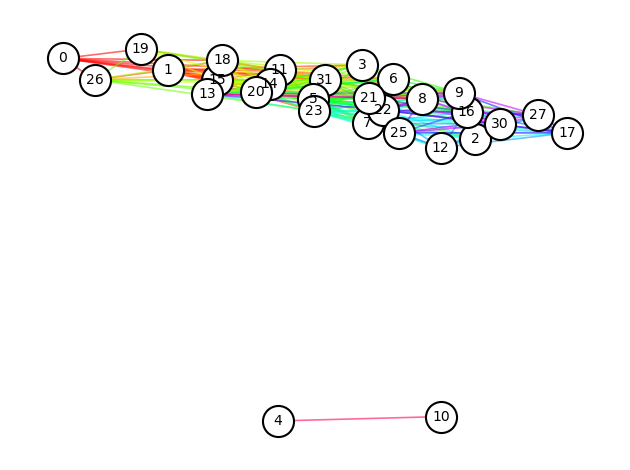

In [467]:
G = nx.Graph()
G.add_edges_from(connections)
pos = nx.spring_layout(G, seed=44)

source_numbers = sorted(set(a for a, b in connections))
hues = np.linspace(0, 1, len(source_numbers), endpoint=False)
source_colors = {
    number: plt.cm.hsv(hue)
    for number, hue in zip(source_numbers, hues)}
edge_colors = [
    source_colors[a]
    for a, b in connections]

# All nodes have exactly the same size
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=500,
    node_color="white",
    edgecolors="black",
    linewidths=1.5
)

# Colored connections
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=1.2,
    alpha=0.58,
    connectionstyle="arc3,rad=0.15"
)

# Number labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [223]:
len(asso_array)

24801